In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Lead Dataset

df = pd.read_csv('customer_sales_data.csv')

print(df.head())

# Basic Information

print(df.columns)

print(df.dtypes)

print(df.shape)

  Customer_ID  Gender  Age   Region Product_Category  Units_Purchased  \
0   CUST_0001    Male   34     East         Clothing                2   
1   CUST_0002  Female   26  Central         Clothing                3   
2   CUST_0003  Female   50    North           Sports                6   
3   CUST_0004  Female   37     East           Beauty                7   
4   CUST_0005    Male   30    North           Beauty                9   

   Price_Per_Unit Purchase_Date  Total_Amount  
0          211.44    2026-02-16        422.88  
1          180.20    2026-02-04        540.60  
2          450.92    2026-07-02       2705.52  
3           20.69    2026-06-18        144.83  
4          335.26    2025-10-30       3017.34  
Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
Customer_ID             str
Gender                  str
Age                   int64
Region                 

In [3]:
# Convert Purchase_date to Datetime

df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

print(df.dtypes)

Customer_ID                    str
Gender                         str
Age                          int64
Region                         str
Product_Category               str
Units_Purchased              int64
Price_Per_Unit             float64
Purchase_Date       datetime64[us]
Total_Amount               float64
dtype: object


In [4]:
# Numpy CAlculation

# Average total amount

average_total = np.mean(df['Total_Amount'])

# Average units Purchased

average_Units_Purchased = np.mean(df['Units_Purchased'])

# Highest Purchase amount

maximum_purchase = np.max(df['Total_Amount'])

# LOwest Purchase amount

minimum_purchase = np.min(df['Total_Amount'])

print("Numpy Calculation")

print("Average Total Amount:" , average_total)

print("Average Units Purchased:" , average_Units_Purchased)

print("Highest Purchase Amount:" , maximum_purchase)

print("Lowest Purchase Amount:" , minimum_purchase)

Numpy Calculation
Average Total Amount: 1283.77586
Average Units Purchased: 4.996
Highest Purchase Amount: 4376.5199999999995
Lowest Purchase Amount: 26.26


In [5]:
# Group Total Sales by order

Gender_sales = df.groupby("Gender")['Units_Purchased'].sum()

print(Gender_sales)

Region_sales = df.groupby("Region")['Units_Purchased'].sum()

print(Region_sales)

Product_Category_sales = df.groupby("Product_Category")['Units_Purchased'].sum()

print(Product_Category_sales)

monthly_purchase = df.groupby(df['Purchase_Date'].dt.to_period('M')).size()

print(monthly_purchase)


weekly_purchase = df.groupby(df['Purchase_Date'].dt.to_period('W')).size()

print(weekly_purchase)

Gender
Female        1210
Male          1159
Non-Binary     129
Name: Units_Purchased, dtype: int64
Region
Central    541
East       488
North      567
South      505
West       397
Name: Units_Purchased, dtype: int64
Product_Category
Beauty            558
Clothing          534
Electronics       492
Home & Kitchen    400
Sports            514
Name: Units_Purchased, dtype: int64
Purchase_Date
2025-09     2
2025-10    50
2025-11    45
2025-12    45
2026-01    32
2026-02    42
2026-03    45
2026-04    37
2026-05    50
2026-06    36
2026-07    40
2026-08    38
2026-09    38
Freq: M, dtype: int64
Purchase_Date
2025-09-29/2025-10-05    11
2025-10-06/2025-10-12     9
2025-10-13/2025-10-19    10
2025-10-20/2025-10-26    11
2025-10-27/2025-11-02    14
2025-11-03/2025-11-09     6
2025-11-10/2025-11-16    15
2025-11-17/2025-11-23    11
2025-11-24/2025-11-30    10
2025-12-01/2025-12-07     8
2025-12-08/2025-12-14    14
2025-12-15/2025-12-21     9
2025-12-22/2025-12-28    10
2025-12-29/2026-01-04  

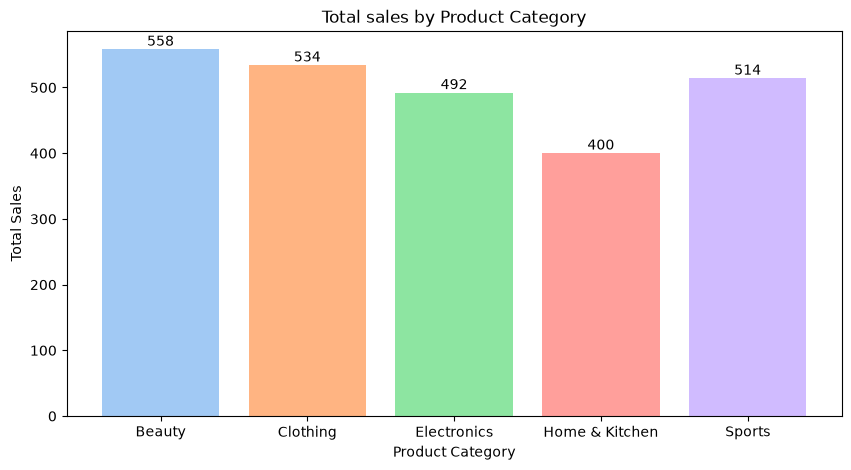

In [18]:
# Visulizatopn

# Bar chart - total sales by product category

plt.figure(figsize=(10 , 5))

plt.bar(
    Product_Category_sales.index,
    Product_Category_sales.values,
    color=sns.color_palette("pastel")
)

plt.title("Total sales by Product Category")

plt.xlabel("Product Category")

plt.ylabel("Total Sales")

# Add value labels on top of each bar
for i, v in enumerate(Product_Category_sales.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')




plt.show()

Region
North      107
East       105
Central    105
South      105
West        78
Name: count, dtype: int64


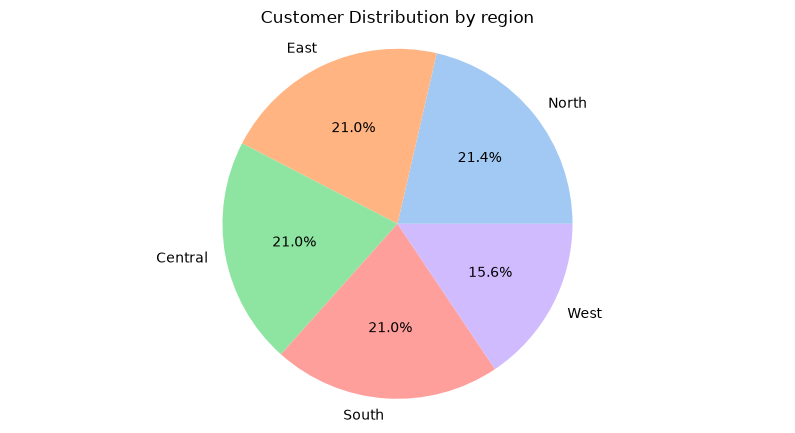

In [20]:
region_customers = df['Region'].value_counts()

print(region_customers)

plt.figure(figsize=(10 , 5))

plt.pie(
    region_customers.values,
    labels=region_customers.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)

plt.title("Customer Distribution by region")
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

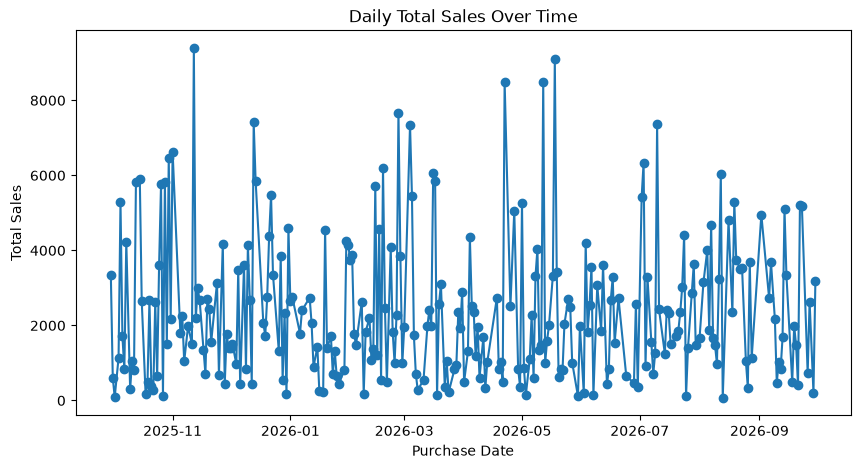

In [8]:
daily_sales = df.groupby("Purchase_Date")["Total_Amount"].sum()

plt.figure(figsize=(10 , 5))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker="o"
)

plt.title("Daily Total Sales Over Time")

plt.xlabel("Purchase Date")

plt.ylabel("Total Sales")

plt.show()

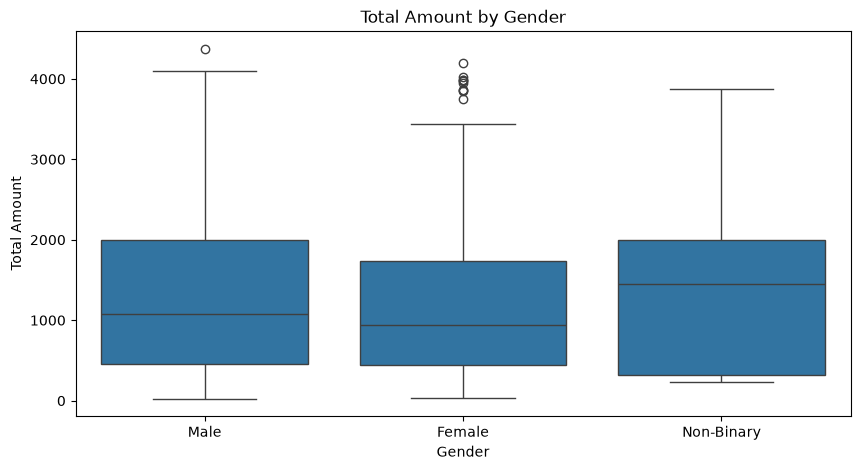

In [9]:
# Seaborn Box Plot

plt.figure(figsize=(10 , 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Total_Amount"
)

plt.title("Total Amount by Gender")

plt.xlabel("Gender")

plt.ylabel("Total Amount")

plt.show()

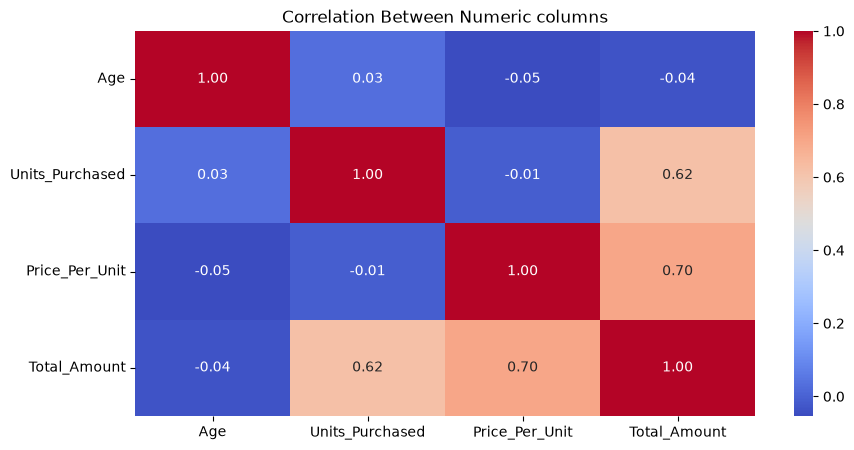

In [10]:
# Heatmap in seaborn

numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()

plt.figure(figsize=(10 , 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.xticks(rotation=0)

plt.title("Correlation Between Numeric columns")

plt.show()

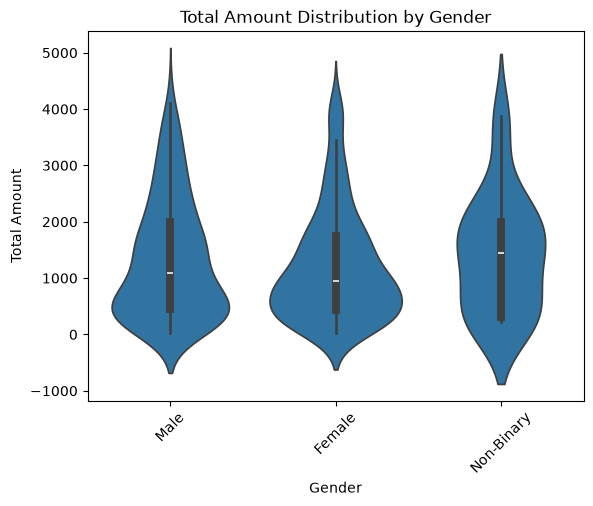

In [15]:
sns.violinplot(
    x="Gender",
    y="Total_Amount",
    data=df
)

plt.title("Total Amount Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()